In [1]:
import csv

def retrieve_data(file_path):
    positions = []
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            x = float(row[0])
            y = float(row[1])
            positions.append((x, y))

    return positions

In [86]:
import matplotlib.pyplot as plt
import numpy as np

def map_positions(data):
    data = np.array(data)
    plt.plot(data[:, 0], data[:, 1])
    plt.text(data[0, 0], data[0, 1], "Start", fontsize=12, verticalalignment='bottom')
    plt.text(data[-1, 0], data[-1, 1], "End", fontsize=12, verticalalignment='bottom')
    # plt.xlim(0, max(data[:, 0]) + 1)  # Add padding for better visibility
    # plt.ylim(0, max(data[:, 1]) + 1)  # Add padding for better visibility
    plt.axes('off')
    plt.show()

In [3]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def orient_positions(start_translation, start_axes_angle, positions):

    translation = start_translation
    axis = start_axes_angle[:3]
    angle = start_axes_angle[3]

    # normalize the axis
    axis = np.array(axis) / np.linalg.norm(axis)

    # Create a rotation matrix from the axis and angle
    rotation_vector = axis * angle
    rotation = R.from_rotvec(rotation_vector)

    # Offset translation
    positions = [
        (
            (x + translation[0]),
            (y + translation[1]),
            0
        )
        for x, y in positions
    ]

    positions = np.array(positions)
    rotated_positions = rotation.apply(positions)
    positions = [
        (
            x,
            y
        )
        for x, y, z in rotated_positions
    ]

    return positions

In [98]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

map_image_path = "apartment.jpg"
img = plt.imread(map_image_path)

def overlayed_map_positions(data, color):
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the background image
    # extent specifies the left, right, bottom, and top sides of the image.
    # Ensure that the extent covers the range of the data appropriately.
    # bottom_left = (-1, -.5)
    # top_right = (11.5, 10)

    min_x = min([x for x, y in data]) - 1
    max_x = max([x for x, y in data]) + 1
    min_y = min([y for x, y in data]) - 1
    max_y = max([y for x, y in data]) + 1
    bottom_left = (min_x, min_y)
    top_right = (max_x, max_y)

    ax.imshow(img, extent=[bottom_left[0], top_right[0], bottom_left[1], top_right[1]], aspect='auto')

    # Convert your data to a NumPy array
    data = np.array(data)
    points = np.array([data[:, 0], data[:, 1]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize colors over the length of the data
    norm = Normalize(vmin=0, vmax=len(data)-1)

    # Create a line collection with gradient
    lc = LineCollection(segments, colors=color, linewidth=3)
    lc.set_array(np.arange(len(data)))

    # Add the line collection to the axis
    line = ax.add_collection(lc)

    # Set limits based on the data
    ax.set_xlim([min(bottom_left[0], data[:, 0].min()), max(top_right[0], data[:, 0].max())])
    ax.set_ylim([min(bottom_left[1], data[:, 1].min()), max(top_right[1], data[:, 1].max())])

    ax.axis('off')

    # Display the plot
    plt.show()

In [5]:
def calculate_path_length(data):
    return np.sum([
        np.linalg.norm(np.array(data[i]) - np.array(data[i+1]))
        for i in range(len(data) - 1)
    ])

def calculate_max_distance(data):
    # Calculate the max distance from start to all other points
    start = np.array(data[0])
    distances = [
        np.linalg.norm(np.array(point) - start)
        for point in data
    ]
    return max(distances)

## Start Position 1

In [157]:
start_translation = (7.6, 3.5)
start_axes_angle = [0, 0, 1, 0]

### Trial 1

In [107]:
positions = retrieve_data('trial-data/p1t1.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

97.46216437069751

In [108]:
calculate_max_distance(positions)

9.567229957390381

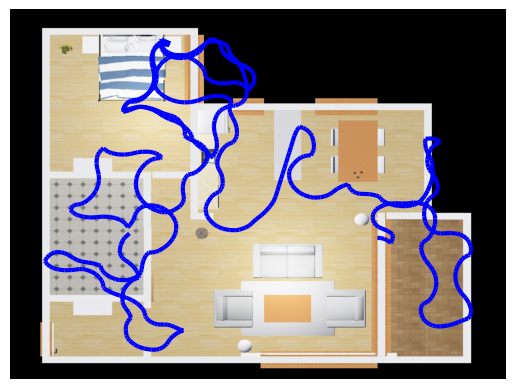

In [109]:
overlayed_map_positions(adjusted_positions, 'blue')

### Trial 2

In [151]:
positions = retrieve_data('trial-data/p1t2.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

76.40039023460244

In [152]:
calculate_max_distance(positions)

8.761604272886752

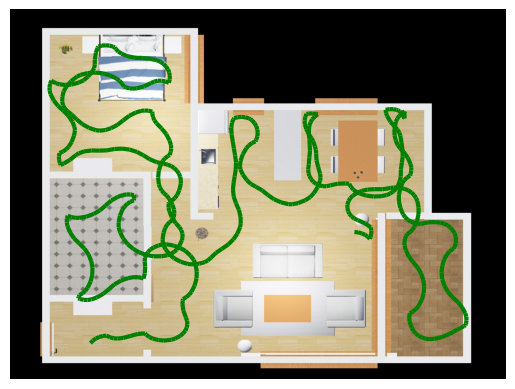

In [153]:
overlayed_map_positions(adjusted_positions, 'green')

### Trial 3

In [154]:
positions = retrieve_data('trial-data/p1t3.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

72.63346966239278

In [155]:
calculate_max_distance(positions)

9.016236420703283

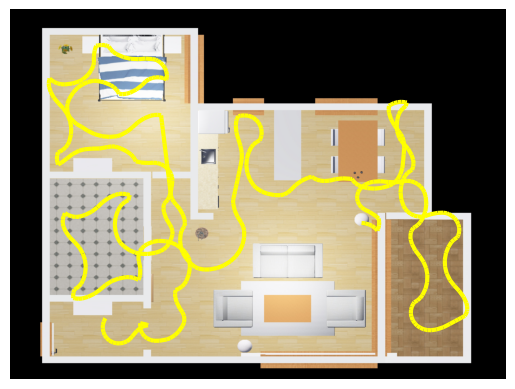

In [156]:
overlayed_map_positions(adjusted_positions, 'yellow')

### Trial 4

In [158]:
positions = retrieve_data('trial-data/p1t4.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

94.28735653285065

In [159]:
calculate_max_distance(positions)

7.658252267765724

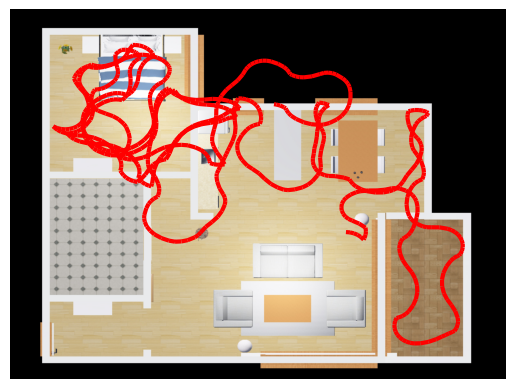

In [160]:
overlayed_map_positions(adjusted_positions, 'red')

### Trial 5

In [ ]:
positions = retrieve_data('trial-data/p1t5.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

In [ ]:
calculate_max_distance(positions)

In [ ]:
overlayed_map_positions(adjusted_positions, 'purple')

## Start Position 2

In [110]:
start_translation = (5.2, 6)
start_axes_angle = [0, 0, 1, 0]

### Trial 1

In [93]:
positions = retrieve_data('trial-data/p2t1.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

89.09196802835231

In [94]:
calculate_max_distance(positions)

7.833287401500771

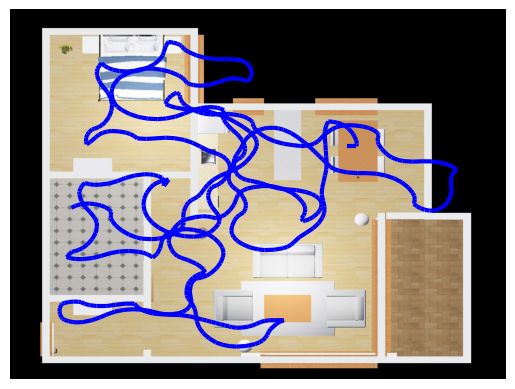

In [99]:
overlayed_map_positions(adjusted_positions, 'blue')

### Trial 2

In [100]:
positions = retrieve_data('trial-data/p2t2.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

86.48843356474158

In [101]:
calculate_max_distance(positions)

7.541811020172234

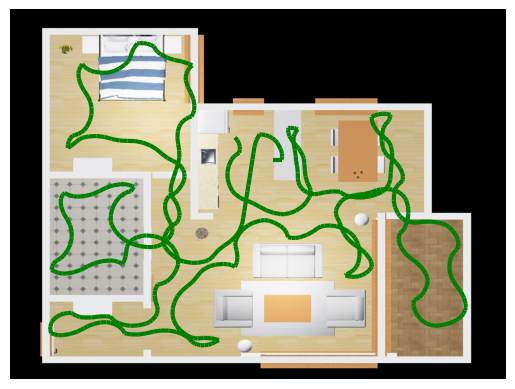

In [102]:
overlayed_map_positions(adjusted_positions, 'green')

### Trial 3

In [103]:
positions = retrieve_data('trial-data/p2t3.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

96.05917339618486

In [104]:
calculate_max_distance(positions)

10.595274922182503

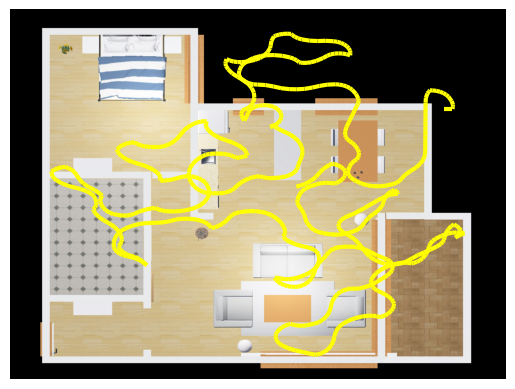

In [105]:
overlayed_map_positions(adjusted_positions, 'yellow')

### Trial 4

In [111]:
positions = retrieve_data('trial-data/p2t4.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

103.32935397336223

In [112]:
calculate_max_distance(positions)

7.20084622911947

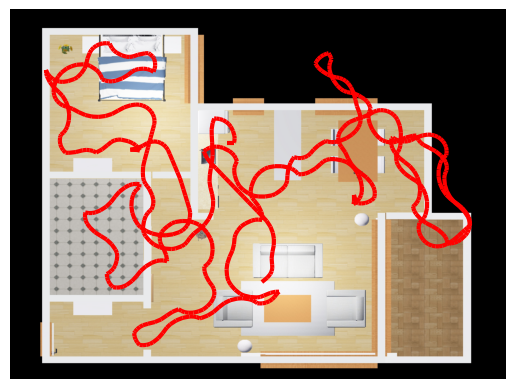

In [113]:
overlayed_map_positions(adjusted_positions, 'red')

### Trial 5

In [114]:
positions = retrieve_data('trial-data/p2t5.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

92.43591368901818

In [115]:
calculate_max_distance(positions)

6.414474075769357

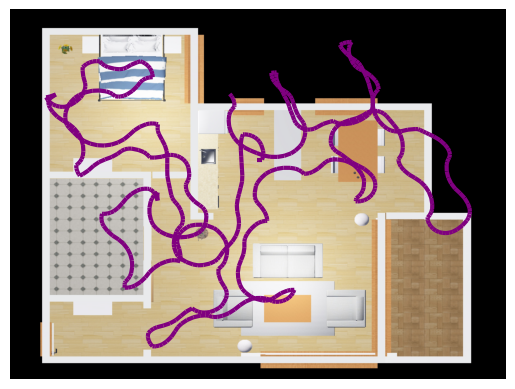

In [116]:
overlayed_map_positions(adjusted_positions, 'purple')

## Start Position 3

In [117]:
start_translation = (1.8, 6.3)
start_axes_angle = [0, 0, 1, -1.57]

### Trial 1

In [118]:
positions = retrieve_data('trial-data/p3t1.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

92.43863841502065

In [119]:
calculate_max_distance(positions)

9.93463523604233

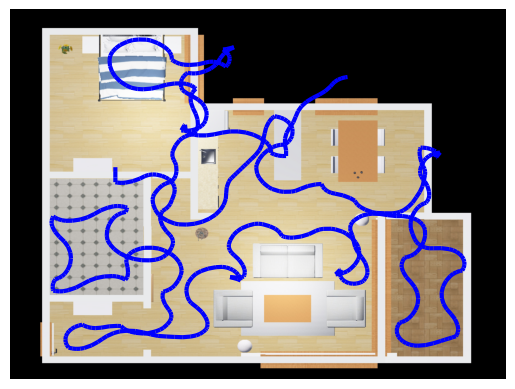

In [120]:
overlayed_map_positions(adjusted_positions, 'blue')

### Trial 2

In [121]:
positions = retrieve_data('trial-data/p3t2.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

83.85600564518211

In [122]:
calculate_max_distance(positions)

7.9207249365450485

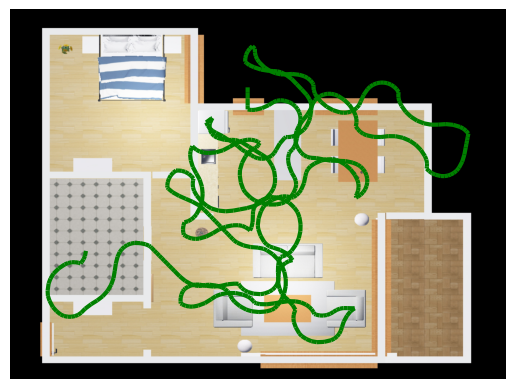

In [123]:
overlayed_map_positions(adjusted_positions, 'green')

### Trial 3

In [124]:
positions = retrieve_data('trial-data/p3t3.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

83.73064872309324

In [125]:
calculate_max_distance(positions)

10.905479147034212

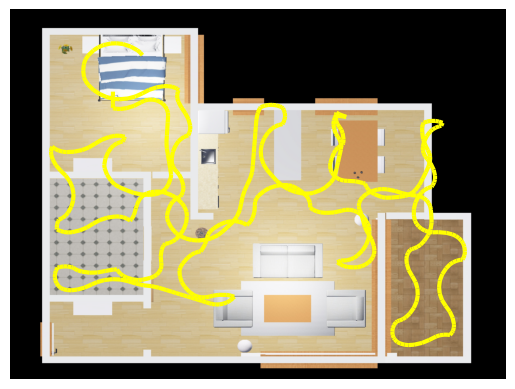

In [126]:
overlayed_map_positions(adjusted_positions, 'yellow')

### Trial 4

In [127]:
positions = retrieve_data('trial-data/p3t4.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

88.23622800735001

In [129]:
calculate_max_distance(positions)

9.322287121054176

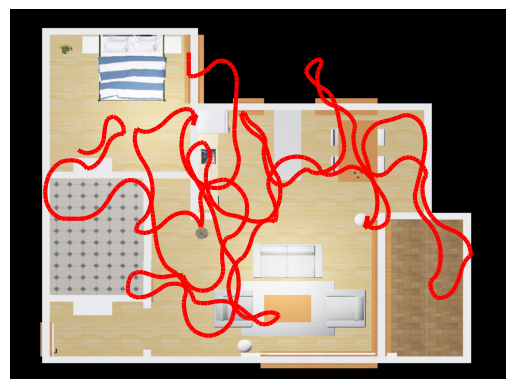

In [130]:
overlayed_map_positions(adjusted_positions, 'red')

### Trial 5

In [131]:
positions = retrieve_data('trial-data/p3t5.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

90.49379847343288

In [132]:
calculate_max_distance(positions)

10.976628605235629

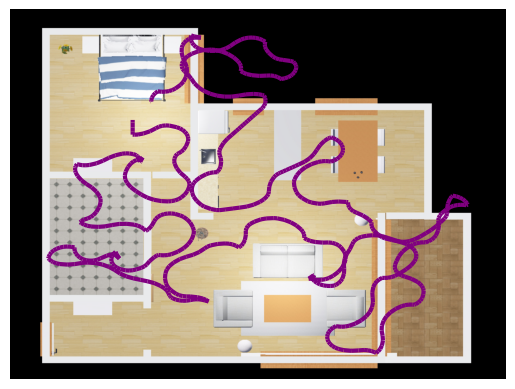

In [133]:
overlayed_map_positions(adjusted_positions, 'purple')

## Position 4

In [134]:
start_translation = (0.96, 0.492)
start_axes_angle = [0, 0, 1, 0]

### Trial 1

In [135]:
positions = retrieve_data('trial-data/p4t1.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

90.49382070454851

In [136]:
calculate_max_distance(positions)

8.237870106163106

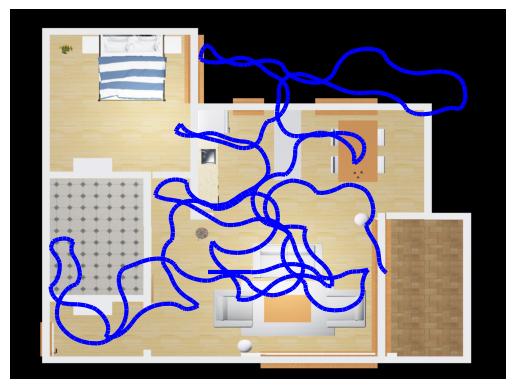

In [137]:
overlayed_map_positions(adjusted_positions, 'blue')

### Trial 2

In [138]:
positions = retrieve_data('trial-data/p4t2.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

127.08323249984934

In [139]:
calculate_max_distance(positions)

8.228972037171523

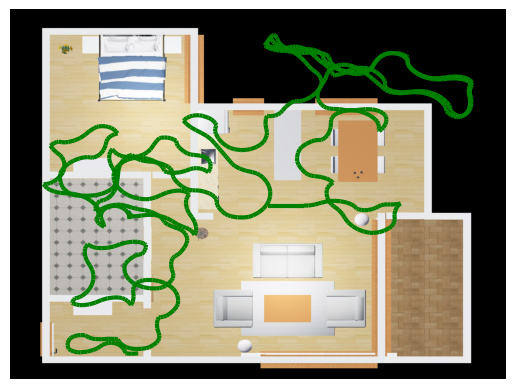

In [140]:
overlayed_map_positions(adjusted_positions, 'green')

### Trial 3

In [141]:
positions = retrieve_data('trial-data/p4t3.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

147.2976046939553

In [142]:
calculate_max_distance(positions)

7.32166437799284

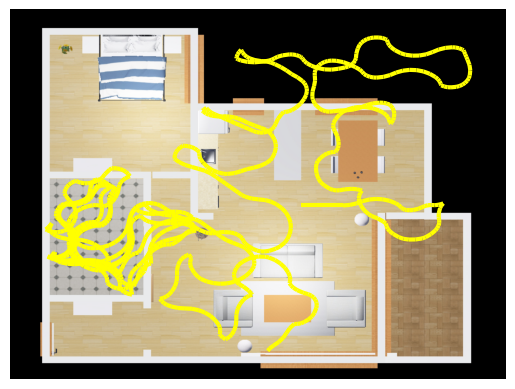

In [143]:
overlayed_map_positions(adjusted_positions, 'yellow')

### Trial 4

In [144]:
positions = retrieve_data('trial-data/p4t4.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

108.33436290167953

In [145]:
calculate_max_distance(positions)

10.397113488116183

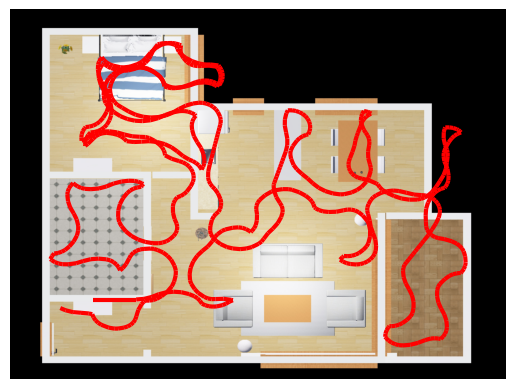

In [146]:
overlayed_map_positions(adjusted_positions, 'red')

### Trial 5

In [147]:
positions = retrieve_data('trial-data/p4t5.csv')
adjusted_positions = orient_positions(start_translation, start_axes_angle, positions)

calculate_path_length(positions)

134.24822051844762

In [148]:
calculate_max_distance(positions)

10.105250607854389

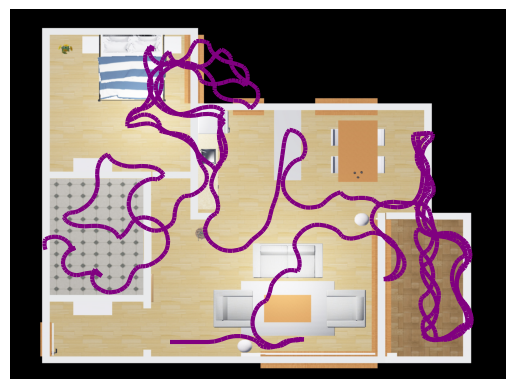

In [149]:
overlayed_map_positions(adjusted_positions, 'purple')